<a href="https://colab.research.google.com/github/CodeShark-pro/Scheduler_Python/blob/main/Research_Mark3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Starting Simulation ---
 Loaded 299726 rows from CSV.
[Cleaning] Data pipeline complete.

Running Baseline Scheduler...
 Green Threshold set at 644.00 gCO2/kWh (Percentile: 100%)

Running Smart Scheduler...
 Green Threshold set at 187.00 gCO2/kWh (Percentile: 30%)

SIMULATION RESULTS
Total Carbon (Baseline):   1,488,310.00 gCO2
Total Carbon (Smart):      1,442,520.00 gCO2
Reduction Achieved:        3.08%
Average Latency Introduced:6.51 hours


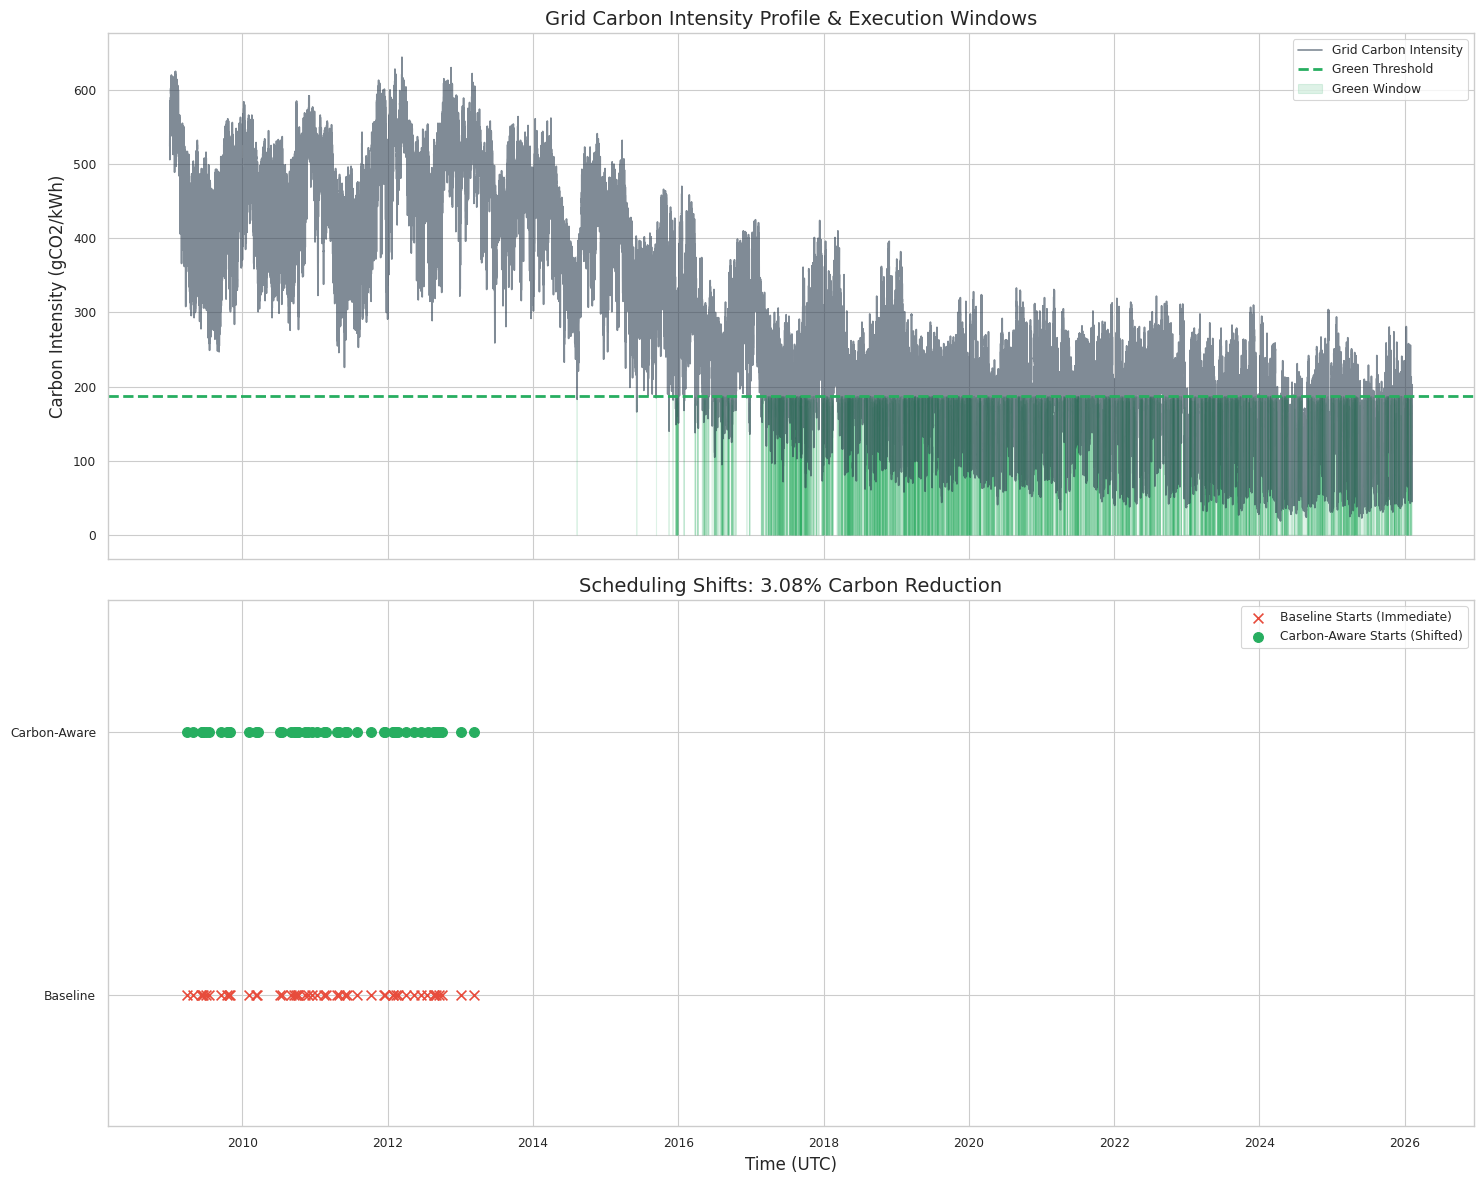

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import random
import warnings

# File path configuration
# Ensure this path is correct in your Colab/Local environment
FILE_PATH = '/content/drive/MyDrive/df_fuel_ckan.csv'

# Suppress minor warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plotting style for academic report quality
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    'font.size': 12,
    'figure.figsize': (14, 8),
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

# =============================================================================
# CLASS 1: ROBUST DATA LOADING & GENERATION
# =============================================================================

class GridDataLoader:
    """
    Handles the ingestion of CSV data. If no file is provided or loading fails,
    it generates synthetic data that mimics the statistical properties of the
    UK National Grid (High volatility, diurnal patterns, wind-driven noise).
    """
    def __init__(self, file_path=None):
        self.file_path = file_path
        self.raw_data = None

    def load_or_generate_data(self):
        """
        Main entry point. Tries to load real data; falls back to synthetic if needed.
        """
        if self.file_path:
            try:
                self._load_csv()
            except Exception as e:
                print(f"[Error] Failed to load CSV: {e}")
                print("[Info] Switching to Synthetic Data Generation.")
                self._generate_synthetic_uk_data()
        else:
            print("[Info] No file path provided. Generating Synthetic UK-like Data.")
            self._generate_synthetic_uk_data()

        return self.raw_data

    def _load_csv(self):
        """
        Loads user CSV. Assumes 'datetime' and 'carbon_intensity' columns exist.
        Performs standardization to UTC and handles column renaming.
        """
        df = pd.read_csv(self.file_path)

        # Normalize column names to lowercase/stripped to avoid KeyErrors
        df.columns = [c.lower().strip() for c in df.columns]

        # Intelligent column mapping: Look for 'date'/'time' and 'carbon'/'intensity'
        time_col = next((c for c in df.columns if 'date' in c or 'time' in c), None)
        int_col = next((c for c in df.columns if 'carbon' in c or 'intensity' in c), None)

        if not time_col or not int_col:
            raise ValueError("CSV must contain timestamp and intensity columns.")

        df = df.rename(columns={time_col: 'timestamp', int_col: 'carbon_intensity'})

        # Standardize Timestamps to UTC
        df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
        df.set_index('timestamp', inplace=True)
        df.sort_index(inplace=True)
        self.raw_data = df
        print(f" Loaded {len(df)} rows from CSV.")

    def _generate_synthetic_uk_data(self):
        """
        Generates data mimicking UK grid physics if CSV load fails:
        - Base: Diurnal cycle (human demand).
        - Variable: Wind power availability (Inverse correlation with some noise).
        - Noise: Sensor jitter.
        """
        # 14 Days of 30-min data
        dates = pd.date_range(start='2024-01-01', periods=48*14, freq='30T')
        n = len(dates)

        # 1. Diurnal Component (Day/Night cycle)
        diurnal = 50 * np.sin(np.linspace(0, 14 * 2 * np.pi, n))

        # 2. Weather Component (Wind fronts passing through)
        weather = 100 * np.sin(np.linspace(0, 4 * 2 * np.pi, n))

        # 3. Baseline & Noise
        baseline = 200
        noise = np.random.normal(0, 10, n)
        ci = baseline + diurnal + weather + noise

        # 4. Inject Outliers & Gaps (to test the Cleaner class)
        spike_indices = np.random.choice(n, 10, replace=False)
        ci[spike_indices[:5]] = 800  # Impossible high
        ci[spike_indices[5:]] = -50  # Impossible low
        gap_indices = np.random.choice(n, 20, replace=False)
        ci[gap_indices] = np.nan

        self.raw_data = pd.DataFrame({'carbon_intensity': ci}, index=dates)
        print("[Info] Synthetic UK-like data generated.")

# =============================================================================
# CLASS 2: ROBUST DATA CLEANING (Z-SCORE & IMPUTATION)
# =============================================================================

class RobustCleaner:
    """
    Preprocessing pipeline to ensure data quality before simulation.
    """
    def __init__(self, dataframe):
        self.df = dataframe.copy()

    def clean(self):
        """
        Pipeline:
        1. Resample to ensure fixed frequency (adds NaNs for missing rows).
        2. Domain Logic: Remove negative values.
        3. Statistical Outliers: Z-Score Filter.
        4. Imputation: Linear Interpolation.
        """
        # 1. Enforce 30-min frequency
        self.df = self.df.resample('30T').asfreq()

        # 2. Domain Logic (Physics Check: Carbon cannot be negative)
        neg_mask = self.df['carbon_intensity'] < 0
        self.df.loc[neg_mask, 'carbon_intensity'] = np.nan

        # 3. Z-Score Outlier Detection
        mu = self.df['carbon_intensity'].mean()
        sigma = self.df['carbon_intensity'].std()
        z_scores = (self.df['carbon_intensity'] - mu) / sigma
        outlier_mask = np.abs(z_scores) > 3.0

        # Only mask if it's not already NaN
        outlier_mask = outlier_mask & (~self.df['carbon_intensity'].isna())
        self.df.loc[outlier_mask, 'carbon_intensity'] = np.nan

        # 4. Imputation (Linear Interpolation)
        self.df['carbon_intensity'] = self.df['carbon_intensity'].interpolate(method='time')
        self.df['carbon_intensity'] = self.df['carbon_intensity'].fillna(method='bfill').fillna(method='ffill')

        print("[Cleaning] Data pipeline complete.")
        return self.df

# =============================================================================
# CLASS 3: SCHEDULER SIMULATION CORE
# =============================================================================

class Task:
    """Represents a delay-tolerant cloud workload (e.g., AI training, Batch processing)."""
    def __init__(self, task_id, arrival_time, duration_slots, power_kw, max_delay_slots):
        self.id = task_id
        self.arrival_time = arrival_time
        self.duration = duration_slots     # 1 slot = 30 mins
        self.power = power_kw              # Average kW draw
        self.max_delay = max_delay_slots   # SLA: Max slots to wait
        self.deadline = arrival_time + timedelta(minutes=30*max_delay_slots)

        # Simulation Results
        self.start_time = None
        self.finish_time = None
        self.carbon_emitted = 0.0
        self.waited_hours = 0.0

class CarbonAwareScheduler:
    """
    The core logic engine. It decides WHEN to run a task based on grid cleanliness.
    """
    def __init__(self, grid_df, percentile_threshold=40):
        self.grid = grid_df
        # Dynamic Threshold: We only run in the cleanest X% of the provided timeline
        self.threshold = np.percentile(self.grid['carbon_intensity'], percentile_threshold)
        print(f" Green Threshold set at {self.threshold:.2f} gCO2/kWh (Percentile: {percentile_threshold}%)")

    def schedule(self, task_list):
        """
        Runs the time-step simulation.
        Iterates through the timeline and manages a waiting queue.
        """
        results = []
        queue = []
        timeline = self.grid.index

        # Sort incoming tasks by arrival time
        incoming = sorted(task_list, key=lambda x: x.arrival_time)

        for current_time in timeline:
            current_ci = self.grid.loc[current_time, 'carbon_intensity']

            # 1. Add new arrivals to queue
            while incoming and incoming[0].arrival_time <= current_time:
                queue.append(incoming.pop(0))

            # 2. Process Queue
            # Iterate backwards or use slice to allow safe removal
            for task in queue[:]:

                # Decision Logic:
                # Condition A: Is the grid currently "Green"?
                is_green = current_ci <= self.threshold

                # Condition B: Deadline Constraint (SLA)
                # If we don't start NOW, will we miss the deadline?
                time_left = task.deadline - current_time
                time_needed = timedelta(minutes=30 * task.duration)
                must_start = time_left <= time_needed

                # Execute if Green OR if Forced by Deadline
                if is_green or must_start:
                    self._execute_task(task, current_time)
                    results.append(task)
                    queue.remove(task)

        return results

    def _execute_task(self, task, start_time):
        """Calculates final carbon impact for a task starting at `start_time`"""
        task.start_time = start_time
        task.finish_time = start_time + timedelta(minutes=30 * task.duration)
        task.waited_hours = (start_time - task.arrival_time).total_seconds() / 3600.0

        # Calculate Carbon: Sum of CI over duration
        end_idx = self.grid.index.get_loc(start_time) + task.duration
        if end_idx > len(self.grid): end_idx = len(self.grid)

        # Get the slice of the grid for the duration of the task
        window = self.grid.iloc[self.grid.index.get_loc(start_time) : end_idx]
        avg_ci = window['carbon_intensity'].mean()

        # Carbon = Power (kW) * Time (h) * CI (g/kWh)
        hours = task.duration * 0.5
        task.carbon_emitted = task.power * hours * avg_ci

# =============================================================================
# MAIN EXECUTION BLOCK & VISUALIZATION
# =============================================================================

def generate_random_workload(df, n_tasks=100):
    """Generates synthetic tasks arriving at random times within the data range."""
    tasks = []
    # Stop generating tasks 2 days before data ends to allow them to finish
    max_idx = len(df) - 48*2

    for i in range(n_tasks):
        rand_idx = random.randint(0, max_idx)
        arrival = df.index[rand_idx]
        duration = random.randint(2, 8) # 1 to 4 hours
        power = 10.0 # 10 kW job
        max_delay = random.randint(6, 48) # SLA: 3 to 24 hours

        tasks.append(Task(i, arrival, duration, power, max_delay))
    return tasks

if __name__ == "__main__":
    # 1. Pipeline Execution
    print("--- Starting Simulation ---")

    # Load Real Data (Uses path defined at top)
    loader = GridDataLoader(FILE_PATH)
    raw_df = loader.load_or_generate_data()

    # Clean Data
    cleaner = RobustCleaner(raw_df)
    clean_df = cleaner.clean()

    # Generate Workload
    workload = generate_random_workload(clean_df, n_tasks=200)

    # 2. Run Comparison
    # Scenario A: Baseline (Immediate Execution, effectively threshold=100%)
    import copy
    print("\nRunning Baseline Scheduler...")
    scheduler_naive = CarbonAwareScheduler(clean_df, percentile_threshold=100)
    results_naive = scheduler_naive.schedule(copy.deepcopy(workload))

    # Scenario B: Carbon Aware (Smart Execution, waits for cleaner grid)
    print("\nRunning Smart Scheduler...")
    scheduler_smart = CarbonAwareScheduler(clean_df, percentile_threshold=30)
    results_smart = scheduler_smart.schedule(copy.deepcopy(workload))

    # 3. Analysis
    total_carbon_naive = sum(t.carbon_emitted for t in results_naive)
    total_carbon_smart = sum(t.carbon_emitted for t in results_smart)
    savings = (1 - total_carbon_smart / total_carbon_naive) * 100
    avg_wait_smart = np.mean([t.waited_hours for t in results_smart])

    print("\n" + "="*40)
    print("SIMULATION RESULTS")
    print("="*40)
    print(f"Total Carbon (Baseline):   {total_carbon_naive:,.2f} gCO2")
    print(f"Total Carbon (Smart):      {total_carbon_smart:,.2f} gCO2")
    print(f"Reduction Achieved:        {savings:.2f}%")
    print(f"Average Latency Introduced:{avg_wait_smart:.2f} hours")
    print("="*40)

    # 4. Visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

    # Graph 1: The Grid & Decisions
    ax1.plot(clean_df.index, clean_df['carbon_intensity'], color='#2c3e50', alpha=0.6, label='Grid Carbon Intensity')
    ax1.axhline(scheduler_smart.threshold, color='#27ae60', linestyle='--', linewidth=2, label='Green Threshold')
    ax1.fill_between(clean_df.index, 0, clean_df['carbon_intensity'],
                     where=(clean_df['carbon_intensity'] <= scheduler_smart.threshold),
                     color='#27ae60', alpha=0.15, label='Green Window')
    ax1.set_ylabel('Carbon Intensity (gCO2/kWh)')
    ax1.set_title('Grid Carbon Intensity Profile & Execution Windows')
    ax1.legend(loc='upper right')

    # Graph 2: Scatter of Start Times
    naive_starts = [t.start_time for t in results_naive[:50]]
    smart_starts = [t.start_time for t in results_smart[:50]]

    ax2.scatter(naive_starts, [1]*len(naive_starts), color='#e74c3c', marker='x', s=50, label='Baseline Starts (Immediate)')
    ax2.scatter(smart_starts, [2]*len(smart_starts), color='#27ae60', marker='o', s=50, label='Carbon-Aware Starts (Shifted)')

    ax2.set_ylim(0.5, 2.5)
    ax2.set_yticks([1, 2])
    ax2.set_yticklabels(['Baseline', 'Carbon-Aware'])
    ax2.set_xlabel('Time (UTC)')
    ax2.set_title(f'Scheduling Shifts: {savings:.2f}% Carbon Reduction')
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')